## 0. Verificación e imports

In [1]:
import os, sys

# Verificar que los módulos están presentes antes de correr
modulos = ['filtrado.py', 'parcelacion.py', 'conectividad.py', 'visor.py']
faltantes = [m for m in modulos if not os.path.exists(m)]

if faltantes:
    print('ERROR — faltan los siguientes archivos en esta carpeta:')
    for f in faltantes:
        print(f'  ✗ {f}')
    print('\nPonelos en la misma carpeta que este notebook y volvé a correr.')
else:
    print('Módulos encontrados:')
    for m in modulos:
        print(f'  ✓ {m}')

ERROR — faltan los siguientes archivos en esta carpeta:
  ✗ filtrado.py
  ✗ parcelacion.py
  ✗ conectividad.py
  ✗ visor.py

Ponelos en la misma carpeta que este notebook y volvé a correr.


In [2]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from nilearn import datasets
import time
import sys
sys.path.append("./script")

# Módulos del pipeline
from script.filtrado     import get_tr, bandpass_filter, filtrar_rois, zscore_rois
from script.parcelacion  import cargar_atlas, extraer_senales_roi, precalcular_cache_roi
from script.conectividad import correlacion, correlacion_parcial, graphical_lasso, comparar_matrices, umbralizar
from script.visor        import visor_cortes, visor_senal_voxel, visor_parcelacion, visor_conectividad

## 1. Cargar datos

Se descarga 1 sujeto del dataset ABIDE (pre-procesado con cpac).  
No descargues todos — son ~70–90 GB. El flujo es: descargar → procesar → borrar, guardar solo el resultado.

> **Nota sobre el TR:** ABIDE es un dataset multi-sitio. Cada sitio de adquisición
> usa parámetros distintos — el TR varía entre 1.5s y 3.0s dependiendo del sitio.
> Por eso el TR se extrae del header NIfTI de cada sujeto con `get_tr()`,
> nunca se asume un valor fijo.


In [3]:
t0 = time.time()

abide = datasets.fetch_abide_pcp(
    data_dir='./data',
    n_subjects=1,
    pipeline='cpac',
    band_pass_filtering=False,   # filtramos nosotros manualmente
    global_signal_regression=False,
    derivatives=['func_preproc']
)

fmri_img  = nib.load(abide.func_preproc[0])
fmri_data = fmri_img.get_fdata()

# TR extraído del header del sujeto (varía por sitio en ABIDE)
TR = get_tr(fmri_img)

x_dim, y_dim, z_dim, t_dim = fmri_data.shape

print(f'Archivo : {abide.func_preproc[0]}')
print(f'Shape   : {fmri_data.shape}  (X, Y, Z, T)')
print(f'TR      : {TR}s  ← extraído del header de este sujeto')
print(f'Tiempo  : {time.time()-t0:.1f}s')

TR extraído del header: 1.5s
Archivo : ./data\ABIDE_pcp\cpac\nofilt_noglobal\Pitt_0050003_func_preproc.nii.gz
Shape   : (61, 73, 61, 196)  (X, Y, Z, T)
TR      : 1.5s  ← extraído del header de este sujeto
Tiempo  : 3.7s


## 2. Exploración visual

Navegación de cortes axiales con slider de z y timepoint.

In [4]:
visor_cortes(fmri_data)

interactive(children=(IntSlider(value=30, description='z', max=60), IntSlider(value=0, description='t', max=19…

## 3. Señal temporal por voxel

Clic en cualquier voxel → señal original y filtrada (0.01–0.1 Hz) usando el TR de este sujeto.

In [5]:
visor_senal_voxel(fmri_data, bandpass_filter, TR)

interactive(children=(IntSlider(value=30, description='z', max=60), Output()), _dom_classes=('widget-interact'…

## 4. Atlas y parcelación

Se usa el atlas Harvard-Oxford cortical. El atlas se remuestrea al espacio
del fMRI y se extrae la señal promedio de cada ROI.  
Solo se incluyen ROIs con al menos 100 voxeles.

Para cambiar de atlas pasá el parámetro `atlas_name`:
- `'cort-maxprob-thr25-2mm'`  Harvard-Oxford cortical (default)
- `'sub-maxprob-thr25-2mm'`   Harvard-Oxford subcortical
- `'AAL'`                     Automated Anatomical Labeling


In [7]:
t0 = time.time()
atlas_data, atlas_obj = cargar_atlas(fmri_img, atlas_name='destrieux_2009')
print(f'Tiempo: {time.time()-t0:.5f}s')

Cargando atlas: destrieux_2009...

Dataset created in C:\Users\crist/nilearn_data\destrieux_2009



 ...done. (1 seconds, 0 min)
Extracting data from C:\Users\crist/nilearn_data\destrieux_2009\2a2e5a5707983d509d9319c692c867ab\destrieux2009.tgz..... done.


Atlas listo. Shape: (61, 73, 61) | Regiones: 151
Tiempo: 1.49921s


In [8]:
t0 = time.time()
roi_signals, selected_rois, roi_names, roi_sizes = extraer_senales_roi(
    fmri_data, atlas_data, atlas_obj, min_voxels=100
)
print(f'Señales ROI shape: {roi_signals.shape}  (T x n_rois)')
print(f'Tiempo: {time.time()-t0:.1f}s')

ROIs incluidas : 102 de 148 (46 excluidas por < 100 voxeles)
Shape señales  : (196, 102)  (T x n_rois)
Señales ROI shape: (196, 102)  (T x n_rois)
Tiempo: 0.5s


In [9]:
# Pre-calcular cache (señal orig + filtrada por ROI) — necesario para los visores
# Usa el TR de este sujeto para filtrar
t0 = time.time()
roi_signal_cache, roi_name_map, roi_sizes_all = precalcular_cache_roi(
    fmri_data, atlas_data, atlas_obj, bandpass_filter, TR, min_voxels=100
)
print(f'Tiempo: {time.time()-t0:.1f}s')

Pre-calculando cache de ROIs con TR=1.5s (puede tardar ~30s)...
Cache listo: 102 ROIs precalculadas.
Tiempo: 0.7s


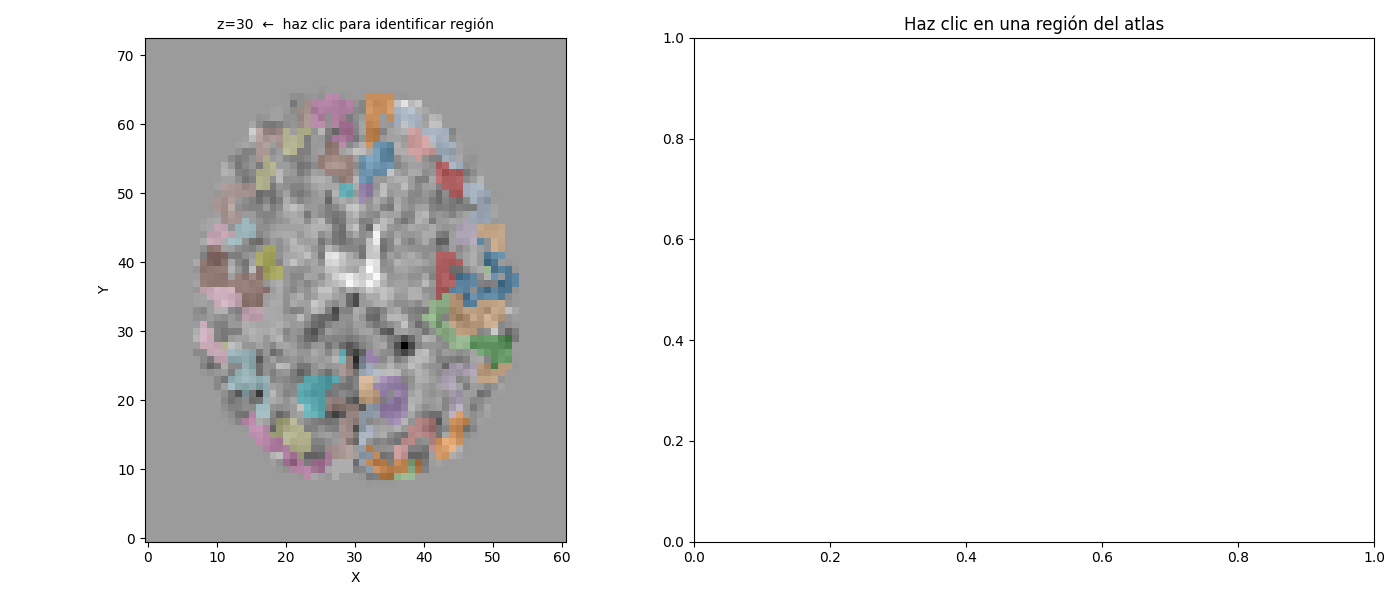

In [10]:
roi_ids_all = [int(i) for i in np.unique(atlas_data) if i != 0]
visor_parcelacion(fmri_data, atlas_data, roi_signal_cache,
                  roi_name_map, roi_ids_all, roi_sizes_all)

## 5. Filtrado y z-score de señales ROI

Dos pasos de pre-procesamiento antes de calcular conectividad:

1. **Filtro pasa-banda** (0.01–0.1 Hz): elimina drift del escáner y ruido fisiológico.  
   Usa el TR de **este sujeto** — crítico en ABIDE donde el TR varía por sitio.
2. **Z-score**: estandariza cada ROI a media=0 y std=1, evitando que ROIs  
   con mayor amplitud dominen la matriz de conectividad.


In [11]:
t0 = time.time()

# Filtrado con el TR del sujeto actual
roi_signals_filt = filtrar_rois(roi_signals, TR)

# Z-score sobre las señales filtradas
roi_signals_z = zscore_rois(roi_signals_filt)

print(f'Shape filtradas : {roi_signals_filt.shape}')
print(f'Shape z-score   : {roi_signals_z.shape}')
print(f'Tiempo          : {time.time()-t0:.1f}s')

Shape filtradas : (196, 102)
Shape z-score   : (196, 102)
Tiempo          : 0.3s


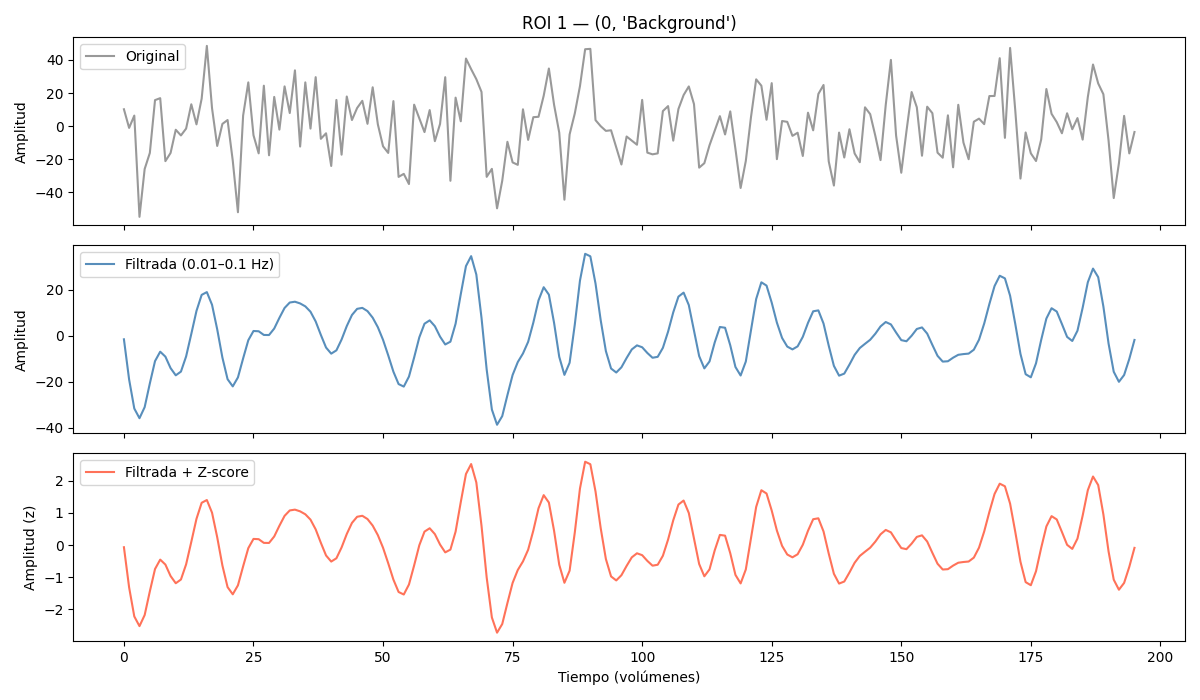

In [12]:
# Comparación visual: primera ROI — cruda, filtrada y z-score
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

axes[0].plot(roi_signals[:, 0], color='gray', alpha=0.8, label='Original')
axes[0].set_title(f'ROI {selected_rois[0]} — {roi_names[0]}')
axes[0].set_ylabel('Amplitud'); axes[0].legend()

axes[1].plot(roi_signals_filt[:, 0], color='steelblue', alpha=0.9, label='Filtrada (0.01–0.1 Hz)')
axes[1].set_ylabel('Amplitud'); axes[1].legend()

axes[2].plot(roi_signals_z[:, 0], color='tomato', alpha=0.9, label='Filtrada + Z-score')
axes[2].set_ylabel('Amplitud (z)'); axes[2].set_xlabel('Tiempo (volúmenes)'); axes[2].legend()

plt.tight_layout()
plt.show()

## 6. Conectividad funcional

Se calculan tres matrices de conectividad sobre las señales **filtradas + z-score**:

| Método | Qué mide | Distingue directo/indirecto |
|--------|----------|----------------------------|
| Correlación de Pearson | Similitud lineal entre señales | No |
| Correlación parcial | Correlación controlando otras ROIs | Parcialmente |
| Graphical Lasso (`precision`) | Conectividad condicional pura | Sí |


In [13]:
t0 = time.time()
corr_matrix = correlacion(roi_signals_z)
print(f'Correlación      — shape: {corr_matrix.shape}  ({time.time()-t0:.1f}s)')

t0 = time.time()
pc_matrix = correlacion_parcial(roi_signals_z)
print(f'Corr. parcial    — shape: {pc_matrix.shape}  ({time.time()-t0:.1f}s)')

t0 = time.time()
gl_matrix = graphical_lasso(roi_signals_z)
print(f'Graphical Lasso  — shape: {gl_matrix.shape}  ({time.time()-t0:.1f}s)')

Correlación      — shape: (102, 102)  (0.0s)
Corr. parcial    — shape: (102, 102)  (0.0s)
Graphical Lasso  — shape: (102, 102)  (0.0s)


In [14]:
# Umbralizar GL para limpiar entradas de ruido numérico
gl_matrix_thr = umbralizar(gl_matrix, threshold=0.01)

Umbral=0.01: 10238 de 10302 entradas no nulas (99.4%)


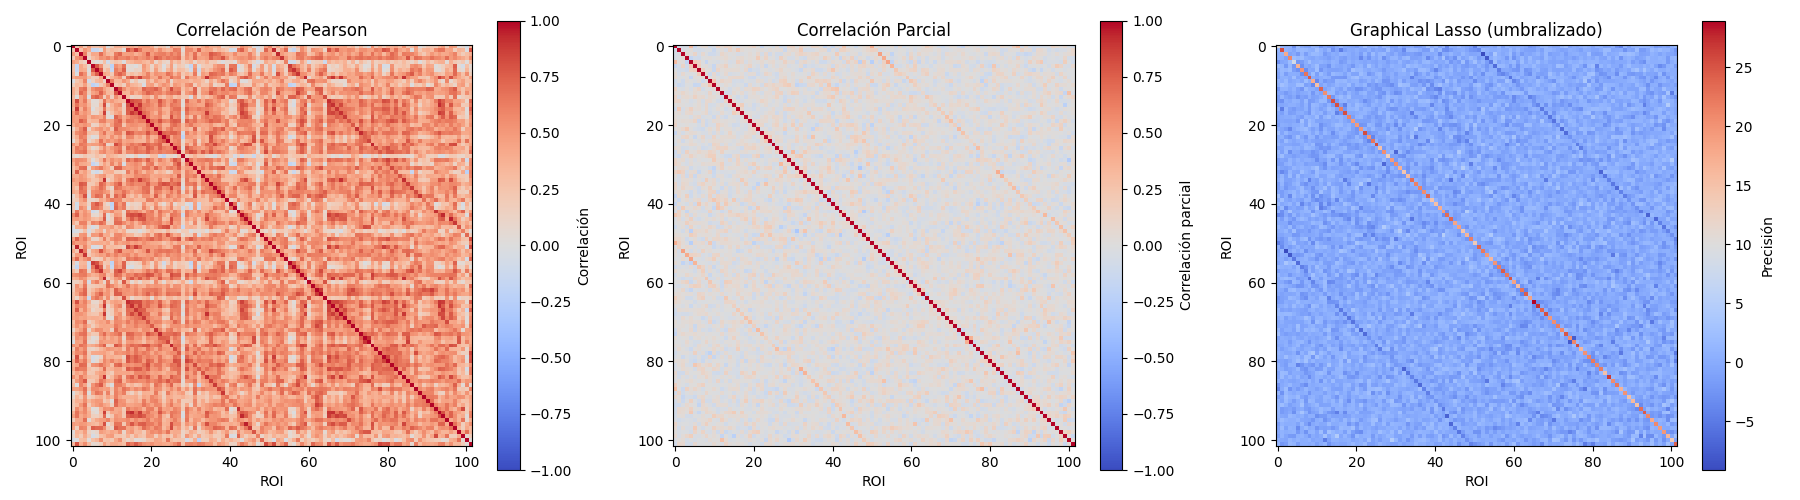

In [15]:
# Visualizar las tres matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
axes[0].set_title('Correlación de Pearson')
axes[0].set_xlabel('ROI'); axes[0].set_ylabel('ROI')
fig.colorbar(im0, ax=axes[0], label='Correlación')

im1 = axes[1].imshow(pc_matrix, cmap='coolwarm', vmin=-1, vmax=1)
axes[1].set_title('Correlación Parcial')
axes[1].set_xlabel('ROI'); axes[1].set_ylabel('ROI')
fig.colorbar(im1, ax=axes[1], label='Correlación parcial')

im2 = axes[2].imshow(gl_matrix_thr, cmap='coolwarm')
axes[2].set_title('Graphical Lasso (umbralizado)')
axes[2].set_xlabel('ROI'); axes[2].set_ylabel('ROI')
fig.colorbar(im2, ax=axes[2], label='Precisión')

plt.tight_layout()
plt.show()

In [16]:
comparar_matrices(corr_matrix, gl_matrix, selected_rois, roi_names)

=== Correlación de Pearson ===
  Media  : 0.4593
  Std    : 0.2007
  Min/Max: -0.2197 / 0.9504

=== Graphical Lasso (precisión) ===
  Media  : -0.1967
  Std    : 1.4399
  Min/Max: -9.1391 / 4.9912
  No nulas (tri. sup): 5151 de 5151 (100.0%)


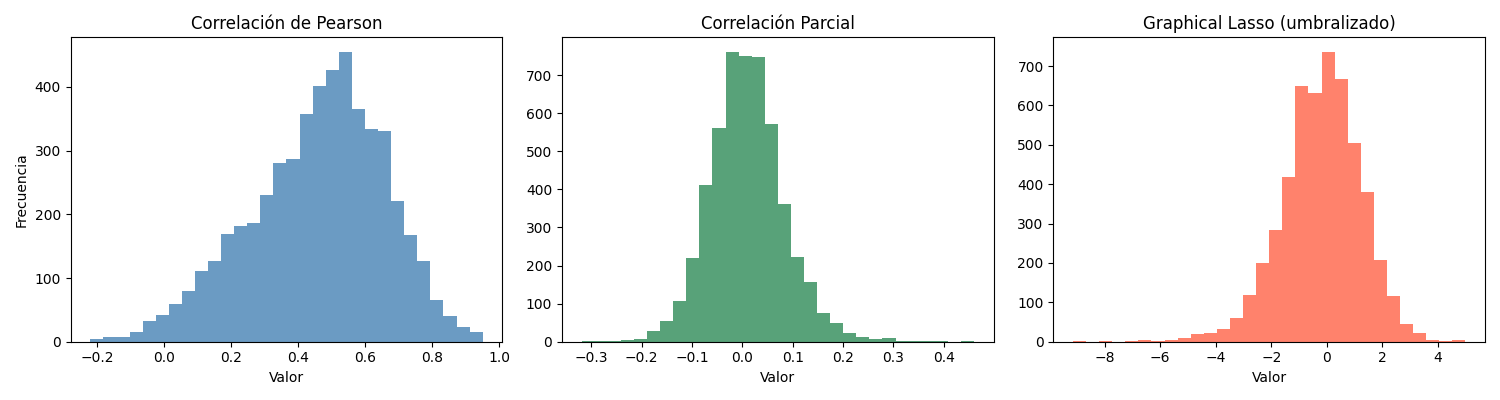

In [17]:
# Distribución de valores (triangular superior)
n     = len(selected_rois)
upper = np.triu_indices(n, k=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(corr_matrix[upper], bins=30, color='steelblue', alpha=0.8)
axes[0].set_title('Correlación de Pearson')
axes[0].set_xlabel('Valor'); axes[0].set_ylabel('Frecuencia')

axes[1].hist(pc_matrix[upper], bins=30, color='seagreen', alpha=0.8)
axes[1].set_title('Correlación Parcial')
axes[1].set_xlabel('Valor')

axes[2].hist(gl_matrix_thr[upper], bins=30, color='tomato', alpha=0.8)
axes[2].set_title('Graphical Lasso (umbralizado)')
axes[2].set_xlabel('Valor')

plt.tight_layout()
plt.show()

## 7. Visor de conectividad por ROI

Clic en una región → mapa de correlación 3D usando esa ROI como semilla.

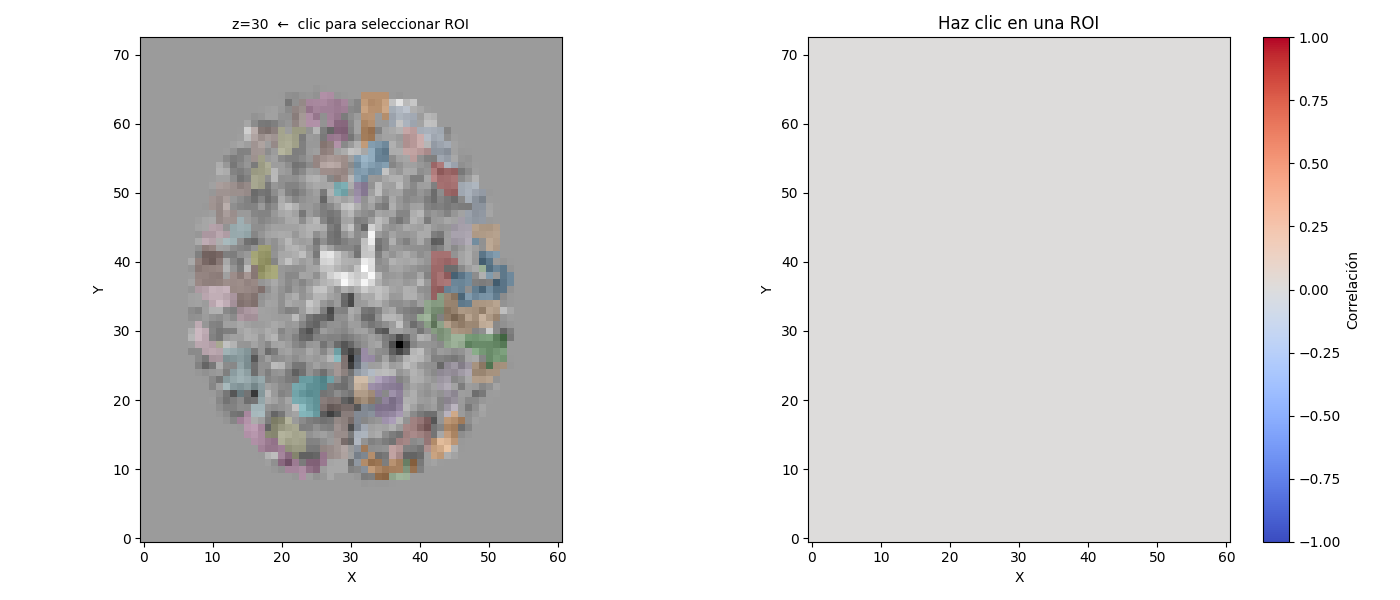

In [18]:
visor_conectividad(fmri_data, atlas_data, roi_signal_cache,
                   roi_name_map, roi_ids_all)

## 8. Guardar resultados

Se guardan las matrices y señales. El sujeto descargado puede borrarse después.


In [19]:
import os
os.makedirs('resultados', exist_ok=True)

np.save('resultados/roi_signals_orig.npy', roi_signals)
np.save('resultados/roi_signals_filt.npy', roi_signals_filt)
np.save('resultados/roi_signals_z.npy',    roi_signals_z)
np.save('resultados/corr_matrix.npy',      corr_matrix)
np.save('resultados/pc_matrix.npy',        pc_matrix)
np.save('resultados/gl_matrix.npy',        gl_matrix)
np.save('resultados/gl_matrix_thr.npy',    gl_matrix_thr)
np.save('resultados/selected_rois.npy',    np.array(selected_rois))
np.save('resultados/roi_names.npy',        np.array(roi_names))

# Guardar TR para referencia 
np.save('resultados/TR.npy', np.array([TR]))

print(f'Guardado en resultados/  (TR={TR}s)')
print('  roi_signals_orig.npy  — señales crudas         (T x ROI)')
print('  roi_signals_filt.npy  — filtradas              (T x ROI)')
print('  roi_signals_z.npy     — filtradas + z-score    (T x ROI)')
print('  corr_matrix.npy       — correlación            (ROI x ROI)')
print('  pc_matrix.npy         — correlación parcial    (ROI x ROI)')
print('  gl_matrix.npy         — graphical lasso        (ROI x ROI)')
print('  gl_matrix_thr.npy     — GL umbralizado         (ROI x ROI)')
print('  TR.npy                — TR del sujeto en segundos')

Guardado en resultados/  (TR=1.5s)
  roi_signals_orig.npy  — señales crudas         (T x ROI)
  roi_signals_filt.npy  — filtradas              (T x ROI)
  roi_signals_z.npy     — filtradas + z-score    (T x ROI)
  corr_matrix.npy       — correlación            (ROI x ROI)
  pc_matrix.npy         — correlación parcial    (ROI x ROI)
  gl_matrix.npy         — graphical lasso        (ROI x ROI)
  gl_matrix_thr.npy     — GL umbralizado         (ROI x ROI)
  TR.npy                — TR del sujeto en segundos


In [20]:
import numpy as np

A = np.load("C:\\Users\\crist\\OneDrive\\Escritorio\\TESIS 1ERA ENTREGA\\Pipeline_manual\\notebooks\\resultados\\corr_matrix.npy")
print(A)

[[ 1.          0.23960489  0.47048303 ...  0.08294556 -0.06318506
   0.33465156]
 [ 0.23960489  1.          0.2598358  ...  0.32139985 -0.01807019
   0.79345023]
 [ 0.47048303  0.2598358   1.         ...  0.17997833  0.28812267
   0.38790463]
 ...
 [ 0.08294556  0.32139985  0.17997833 ...  1.          0.054865
   0.19485593]
 [-0.06318506 -0.01807019  0.28812267 ...  0.054865    1.
   0.03094801]
 [ 0.33465156  0.79345023  0.38790463 ...  0.19485593  0.03094801
   1.        ]]


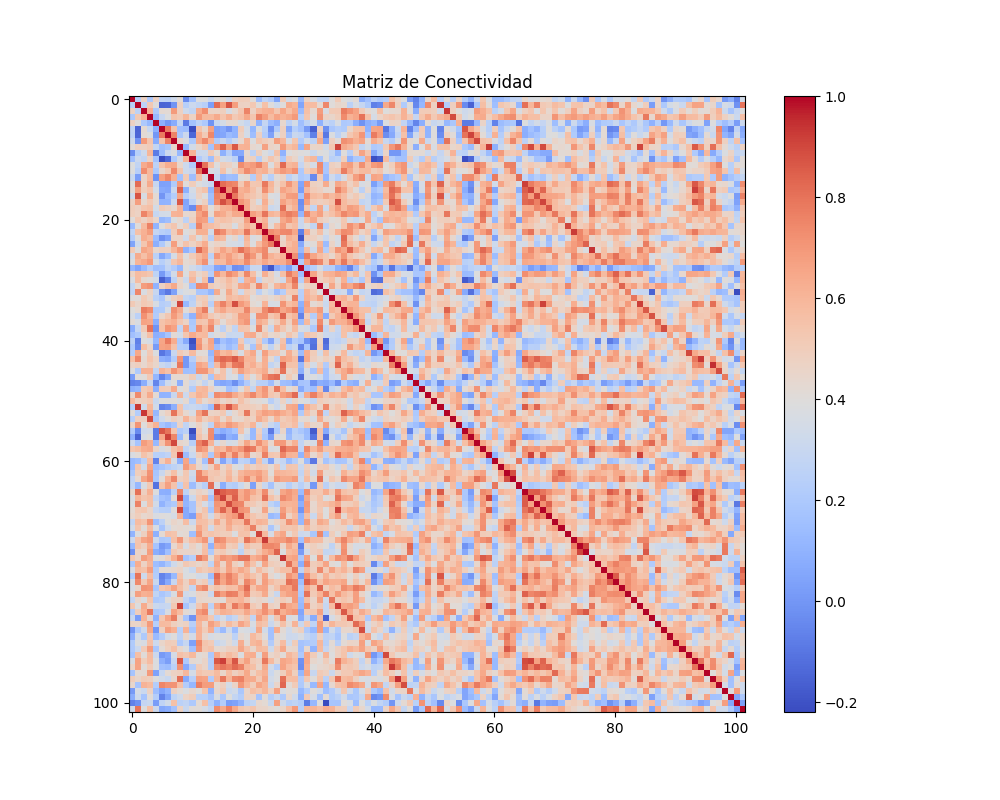

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(A, cmap='coolwarm')
plt.colorbar()
plt.title("Matriz de Conectividad")
plt.show()

In [22]:
A.shape

(102, 102)